# Análisis ConnectaTel


Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [4]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print("total_nulos:",users.isna().sum())
print("porcentaje_nulos:", users.isna().mean())

total_nulos: user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
porcentaje_nulos: user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
print("total_nulos:", usage.isna().sum())
print("porcentaje_nulos:", usage.isna().mean())

total_nulos: id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
porcentaje_nulos: id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64



💡 Caso users: 469 nulos en la columna city(11.17%) y 3534 en la columna churn_date(88.35%), ignorar los datos nulos de la columna churn_date, investigar la columna city para saber si imputar o asignar como nulos.
 Caso Usage: se encontraron nulos en las siguientes columnas; date con 50 (representando el 0.1%), duration con 22076(55.19%), length con 17896(44.74%), acciones a tomar, imputar la columna date, investigar la columna duration y legth para decidir como imputar.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` muestra una media y una mediana exactamente iguales.
- La columna `age` muestra minimos imposibles (-999) dando a entender que se requiere imputar

In [14]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` tienen la mediana y la media muy similares.
- Las columnas `duration` y `length` presentan outliers maximos, ya que el Q3 es mucho menor que el max, revisar como hay que imputar.

In [15]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` tiene nulos, 7 categorias unicas siendo la ciudad de Bogotá la mas repetida con una frecuencia de 808 veces

- La columna `plan` no tiene nulos, mostrando 2 categorias unicas, con Basico como la mas repetida con una frecuencia de mas del 50%

In [16]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` no presenta nulos, tiene 2 unicos siendo text el de mayor frecuencia 22092

---
✍️ **Comentario**: en users, se necesita imputar la columna `age`, ya que presenta sentinnels (-999). 
en usage, se necesita revisar los outliers ya que el Q3 esta muy por debajo del maximo en las columnas `duration` y `length`.
en cuanto a las columnas categoricas de users, se necesita limpiar de nulos y los sentinnels ? de la columna `city`.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] =pd.to_datetime(users['reg_date'],errors= 'coerce', utc= True)

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors='coerce', utc=True)

In [19]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, no aparece el año 2025 y la fecha imposible de 2026, recomendacion excluir o marcar como NA

In [20]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()


2024.0    39950
Name: date, dtype: int64

En `date` solo aparece el año 2024 se requiere marcar fechas duera del rango como nulas.  
Basaremos el análisis en estas fechas.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?',pd.NA)

# Verificar cambios
users['city'].unique()

array(['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [23]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NA
# Verificar cambios
users['reg_date'].describe()

count                                    3960
unique                                   3960
top       2023-12-20 18:33:45.506376600+00:00
freq                                        1
first               2022-01-01 00:00:00+00:00
last                2024-12-31 00:00:00+00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [25]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Diagnostico
-
las columnas `duration`y `length` son MAR, tienen una dependecia a la columna `type` ya que ambas presentan un 99% de NAs en las columnas que no se relacionan, es decir las llamadas no tienen longitud sino duracion, y los textos no tienen duracion sino longitud.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    no_mensajes=('is_text', 'sum'),
    no_llamadas= ('is_call', 'sum'),
    minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,no_mensajes,no_llamadas,minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={"no_mensajes": "cant_mensajes",'no_llamadas':'cant_llamadas','minutos_llamada':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg,users, on =['user_id'], how= 'inner')
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
# Resumen estadístico de las columnas numéricas
columnas_numericas= ['cant_mensajes','cant_llamadas', 'cant_minutos_llamada', 'age']
user_profile[columnas_numericas].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054,48.124531
std,2.358416,2.144238,18.168095,17.692032
min,0.000000,0.000000,0.000000,18.000000
25%,4.000000,3.000000,11.120000,33.000000
50%,5.000000,4.000000,19.780000,47.000000
75%,7.000000,6.000000,31.415000,63.000000
max,17.000000,15.000000,155.690000,79.000000


In [30]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize= True)

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

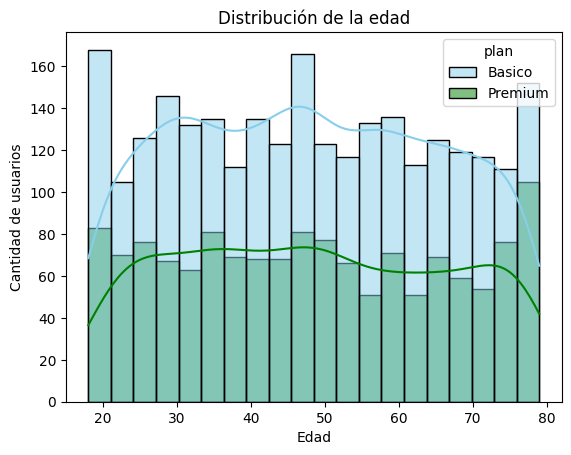

In [31]:
# Histograma para visualizar la edad (age)
sns.histplot(data= user_profile, x='age', hue= 'plan', palette=['skyblue','green'], bins= 20,kde=True)
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de la edad')
plt.xticks()
plt.show()

💡Insights: 
- Distribución cerca de lo normal en ambos planes los del plan basico son más que los que tienen plan premium.

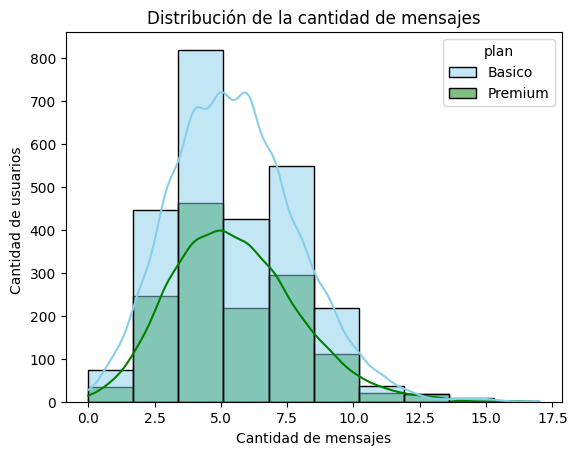

In [32]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data= user_profile, x='cant_mensajes', hue= 'plan', palette=['skyblue','green'], bins= 10,kde=True)
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios ')
plt.title('Distribución de la cantidad de mensajes')
plt.xticks()
plt.show()

💡Insights: 
- Los usuarios del plan basico tienden enviar mas cantidad de mensajes que los usuarios premium, la distribucion es aparentemente normalo se podria decir que ligeramente sesgada a la derecha

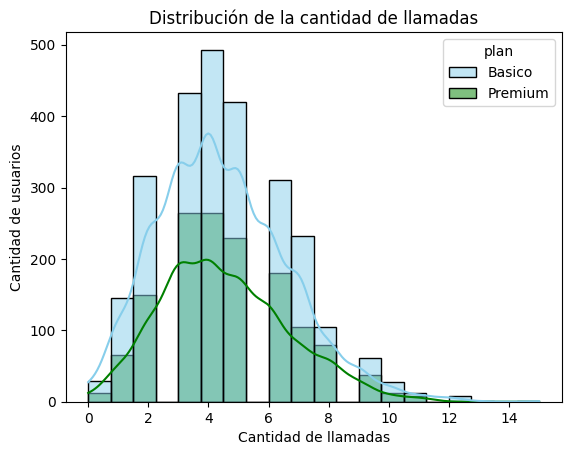

In [33]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data= user_profile, x='cant_llamadas', hue= 'plan', palette=['skyblue','green'], bins= 20,kde=True)
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de la cantidad de llamadas')
plt.xticks()
plt.show()


💡Insights: 
- Distribución aparentemente normal ligera cola a la derecha, los usuarios premium tienen una proporción mayor en comparación con los premium.

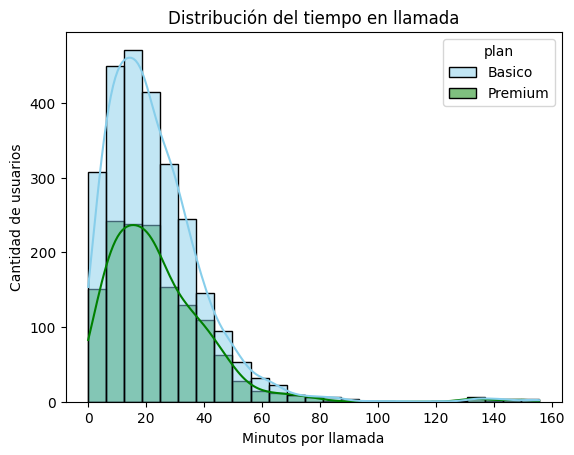

In [34]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data= user_profile, x='cant_minutos_llamada', hue= 'plan', palette=['skyblue','green'], bins= 25,kde=True)
plt.xlabel('Minutos por llamada')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución del tiempo en llamada')
plt.xticks()
plt.show()

💡Insights: 
-Distribucion sesgada a la derecha, la proporcion de minutos por llamada de los usuarios del plan basico es casi el doble que los premium

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

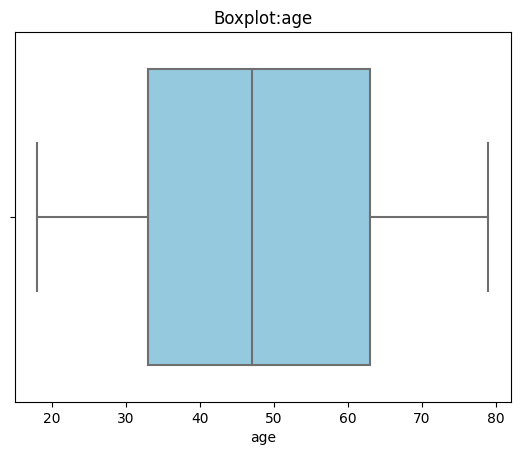

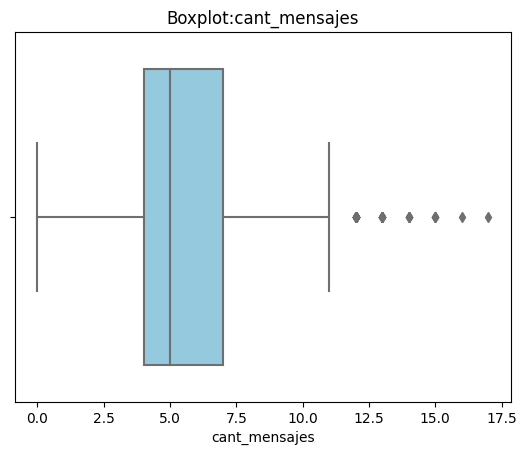

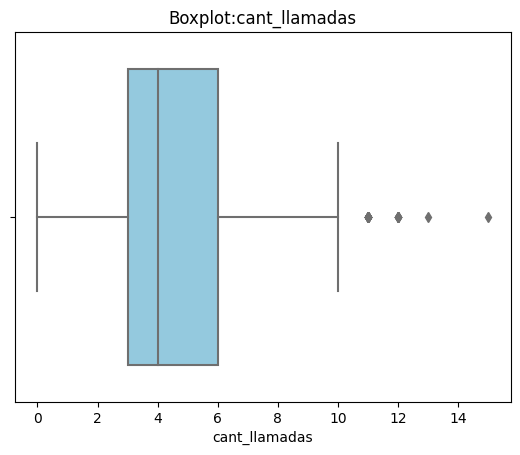

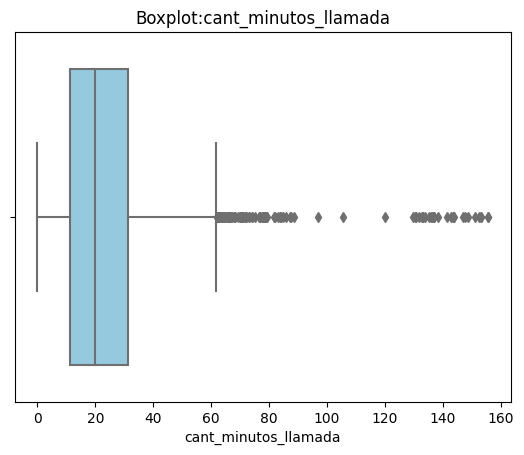

In [35]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data= user_profile, x= col, color='skyblue')
    plt.title(f'Boxplot:{col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers
- cant_mensajes: Existen algunos outliers
- cant_llamadas: Existen algunos outliers
- cant_minutos_llamada: Hay demasiados outliers

In [36]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']

for col in columnas_limites:
    Q3= user_profile[col].quantile(0.75)
    Q1= user_profile[col].quantile(0.25)
    IQR= Q3-Q1
    lower= Q1 - 1.5 * IQR
    upper= Q3 + 1.5 * IQR
    print(f'Limite inferior de {col}', lower)
    print(f'Limite superior de {col}', upper, "\n")



Limite inferior de cant_mensajes -0.5
Limite superior de cant_mensajes 11.5 

Limite inferior de cant_llamadas -1.5
Limite superior de cant_llamadas 10.5 

Limite inferior de cant_minutos_llamada -19.322500000000005
Limite superior de cant_minutos_llamada 61.8575 



In [37]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Mantener por que no hay tanta distancia de los limites calculados a los valores del dataset
- cant_llamadas: mantener o no outliers, porqué? Mantener porque no afectan la estadistica del dataset, no estan tan lejos de los limites.
- cant_minutos_llamada: mantener o no outliers, porqué? Mantener, ya que los valores outliers se deben a usuarios que en si han tenido una larga duracion de llamada, aunque esten muy por encima del maximo limite calculado.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [44]:
# Crear columna grupo_uso
def classify_segment(row):
    mensajes= row["cant_mensajes"]
    llamadas= row["cant_llamadas"]
                                
    if llamadas < 5 and mensajes < 5:
        return "Bajo uso"
    elif llamadas < 10 and mensajes < 10:
        return "Uso medio"
    else: 
        return "Alto uso"

user_profile["grupo_uso"]= user_profile.apply(classify_segment,axis=1)

In [46]:
# verificar cambios
user_profile.head(10)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,Bajo uso,Adulto Mayor
5,10005,5,7,44.97,Luis,Garcia,61.0,MTY,2022-01-02 08:51:29.572393098+00:00,Basico,NaN,Uso medio,Adulto Mayor
6,10006,3,5,28.39,Sofia,Lopez,39.0,Bogotá,2022-01-02 15:25:47.486871717+00:00,Basico,NaN,Uso medio,Adulto
7,10007,3,5,30.23,Sofia,Gomez,70.0,Medellín,2022-01-02 22:00:05.401350337+00:00,Premium,NaN,Uso medio,Adulto Mayor
8,10008,5,5,28.85,Sofia,Garcia,76.0,CDMX,2022-01-03 04:34:23.315828957+00:00,Basico,NaN,Uso medio,Adulto Mayor
9,10009,5,3,5.99,Mateo,Torres,47.0,Bogotá,2022-01-03 11:08:41.230307576+00:00,Basico,NaN,Uso medio,Adulto


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [49]:
# Crear columna grupo_edad
def classify_age(row):
    age= row["age"]
    if age < 30:
        return "Joven"
    elif age < 60:
        return "Adulto"
    else: 
        return "Adulto Mayor"

user_profile["grupo_edad"]=user_profile.apply(classify_age,axis=1)


In [50]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

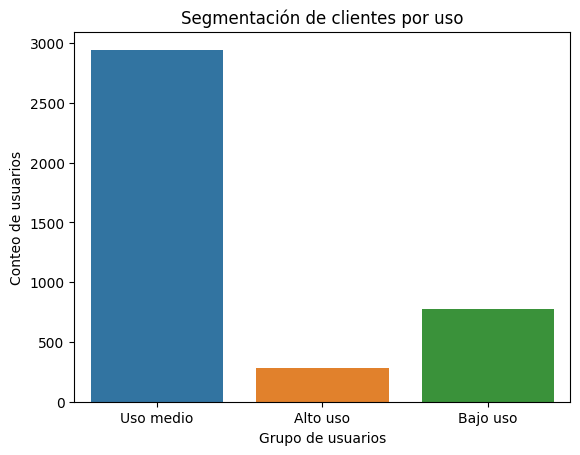

In [51]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x="grupo_uso")
plt.ylabel("Conteo de usuarios")
plt.xlabel("Grupo de usuarios")
plt.title("Segmentación de clientes por uso")
plt.show()

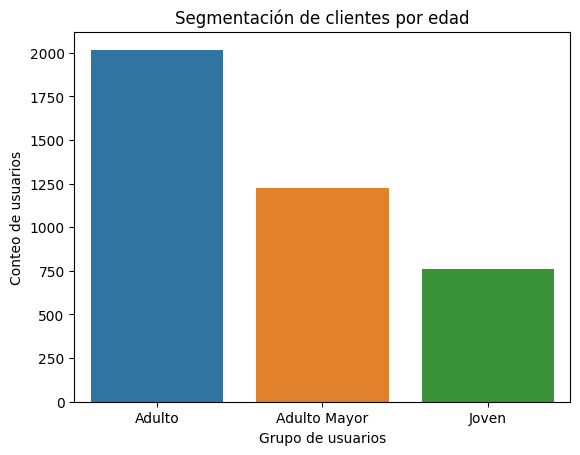

In [52]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad")
plt.ylabel("Conteo de usuarios")
plt.xlabel("Grupo de usuarios")
plt.title("Segmentación de clientes por edad")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
-Age (users): sentinel -999 en ~1.4% de los registros, corregido con la mediana (47).
-city (users): 469 nulos (11.7%) más el sentinel "?".
-reg_date (users): 40 registros (1%) con año 2026, imposible dado el rango de reporte (hasta 2024).
-churn_date (users): 88.4% nulos → indica usuarios activos (no cancelados); churn real 11.6%.
-duration y length (usage): 55.2% y 44.7% de nulos, confirmados como MAR (dependen del type: llamada vs. mensaje), correctamente dejados sin imputar.
-Nuevo hallazgo: al combinar usage_agg con users mediante inner join, se pierde 1 usuario (4,000 → 3,999) que no tiene ningún registro en usage. Vale la pena confirmar si ese usuario debe excluirse del análisis o si es un caso de "usuario sin actividad" que también aporta información de negocio (por ejemplo, riesgo de churn).

🔍 **Segmentos por Edad**
- La edad se distribuye de forma cercana a lo normal en ambos planes, con Básico concentrando más usuarios que Premium.
Los grupos Joven (<30), Adulto (30-60) y Adulto Mayor (>60) muestran que la base de clientes está compuesta mayoritariamente por adultos, lo que sugiere un negocio con clientela madura y potencialmente más estable.

📊 **Segmentos por Nivel de Uso**
- Los usuarios Básico envían más mensajes que los Premium, con una distribución ligeramente sesgada a la derecha.
Los usuarios Premium muestran una proporción relativamente mayor en cantidad de llamadas, aunque son menos usuarios en total.
En minutos totales de llamada, los usuarios Básico casi duplican a los Premium, con una distribución fuertemente sesgada a la derecha.

➡️ **Outliers**
cant_mensajes: límite superior 11.5, máximo real 17 → outliers leves, se mantienen porque no están muy lejos del límite.
cant_llamadas: límite superior 10.5, máximo real 15 → mismo caso, se mantienen.
cant_minutos_llamada: límite superior 61.86 min, máximo real 155.69 min → hay una brecha real, pero no extrema (a diferencia del análisis anterior que hablaba de 626/2028, cifras que quedaron obsoletas tras corregir la agregación). Se recomienda mantenerlos, ya que representan usuarios con llamadas genuinamente largas, es decir, un segmento real de "power users" en minutos, útil para diseño de planes.

💡 **Recomendaciones**
-Diseñar un add-on o plan de minutos ampliados para el segmento de usuarios con cant_minutos_llamada por encima de 62 min (actualmente sin oferta que capture ese consumo).
-Incentivar la migración de usuarios Básico de alto uso hacia Premium, dado su comportamiento ya cercano al de un usuario de alto valor.
-Reforzar retención en Alto uso + Adulto/Adulto Mayor, el segmento más estable.
-Investigar al usuario excluido por el inner join (sin actividad registrada) — podría ser un caso de churn temprano no capturado en churn_date.

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [ ]:
https://github.com/erixamora/telecom_analysis.git